# Simulasi Mekanisme Transpor Membran Sel
## Cell Membrane Transport Simulation

This notebook simulates and compares three fundamental mechanisms of molecular transport across cell membranes:

1. **Simple Diffusion** — passive, gradient-driven (Fick's Law)
2. **Facilitated Diffusion** — passive, protein-mediated with saturation (Michaelis-Menten)
3. **Active Transport** — energy-dependent Na⁺/K⁺ ATPase pump (works against gradients)

All simulation parameters are loaded from `dataset.csv` in the project root.

**Course**: IF3211 Komputasi Domain-Spesifik — Institut Teknologi Bandung

In [9]:
import sys
import os
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Add membrane_transport package to path
sys.path.insert(0, os.path.join(os.getcwd(), 'membrane_transport'))

# Ensure outputs directory exists
OUTPUT_DIR = os.path.join(os.getcwd(), 'membrane_transport', 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('dataset.csv')
df.index = df['symbol']

def p(symbol):
    """Return parameter value, converting mM → mol/L where unit is mM."""
    row = df.loc[symbol]
    val = float(row['value'])
    if row['unit'] == 'mM':
        val = val * 1e-3
    return val

print('Dataset loaded successfully:')
display(df[['parameter', 'symbol', 'value', 'unit', 'source']].reset_index(drop=True))

Dataset loaded successfully:


,parameter,symbol,value,unit,source
0,Diffusion coefficient,D,1.000000e-09,m2/s,"Alberts et al, Molecular Biology of the Cell 6..."
1,Membrane thickness,L,7.000000e-09,m,"Alberts et al, Molecular Biology of the Cell 6..."
2,Initial concentration compartment 1,C1_0,1.000000e+02,mM,"Alberts et al, Molecular Biology of the Cell 6..."
3,Initial concentration compartment 2,C2_0,1.000000e+01,mM,"Alberts et al, Molecular Biology of the Cell 6..."
4,Maximum transport rate,Jmax,1.000000e-05,mol/m2/s,"Lodish et al, Molecular Cell Biology 8th ed, 2016"
5,Michaelis constant,Km,5.000000e+00,mM,"Lodish et al, Molecular Cell Biology 8th ed, 2016"
6,Intracellular sodium,Na_in,1.500000e+01,mM,"Koeppen & Stanton, Berne & Levy Physiology 7th..."
7,Extracellular sodium,Na_out,1.450000e+02,mM,"Koeppen & Stanton, Berne & Levy Physiology 7th..."
8,Intracellular potassium,K_in,1.400000e+02,mM,"Koeppen & Stanton, Berne & Levy Physiology 7th..."
9,Extracellular potassium,K_out,5.000000e+00,mM,"Koeppen & Stanton, Berne & Levy Physiology 7th..."


## 1. Simple Diffusion

**Simple diffusion** is the passive movement of molecules across a lipid bilayer down their concentration gradient — no energy or protein carriers required. The rate is described by **Fick's First Law**:

$$J = -D \cdot \frac{\Delta C}{L}$$

where $D$ is the diffusion coefficient, $\Delta C$ is the concentration difference between compartments, and $L$ is membrane thickness. In a two-compartment system the concentrations relax exponentially toward equilibrium with time constant $\tau = VL / (2DA)$.

Only small, nonpolar molecules (O₂, CO₂, steroid hormones) cross membranes this way efficiently.

Simple Diffusion Results
  D (diffusion coefficient) : 1.00e-09 m²/s
  L (membrane thickness)    : 7.0 nm
  C1 initial                : 100.0 mM
  C2 initial                : 10.0 mM
  Time constant τ           : 3.5000 ms
  Initial flux J₀           : 1.2857e+01 mol/m²/s
  Final flux                : 8.6631e-02 mol/m²/s
  Equilibrium concentration : 55.00 mM


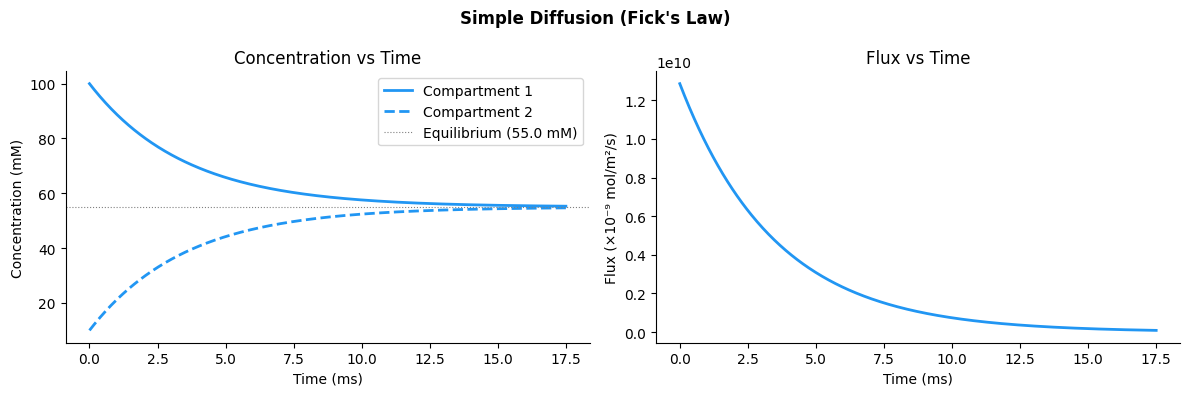

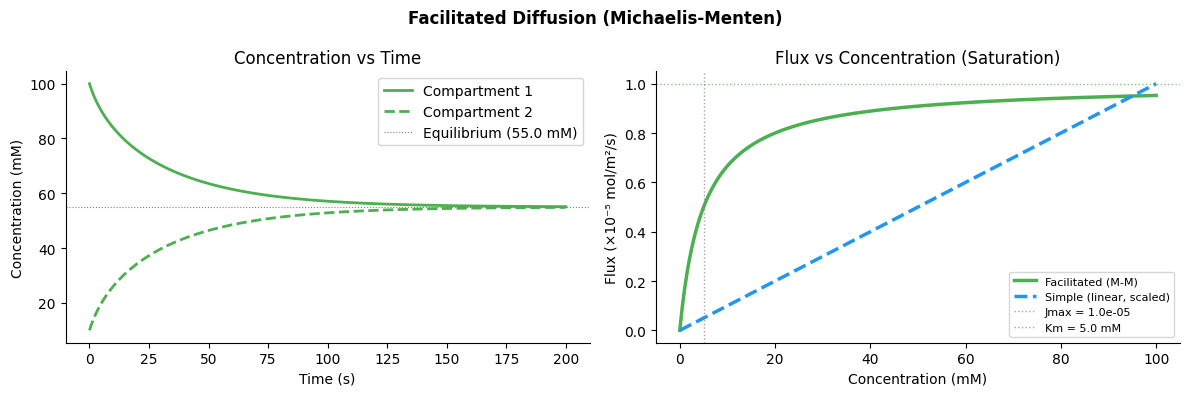

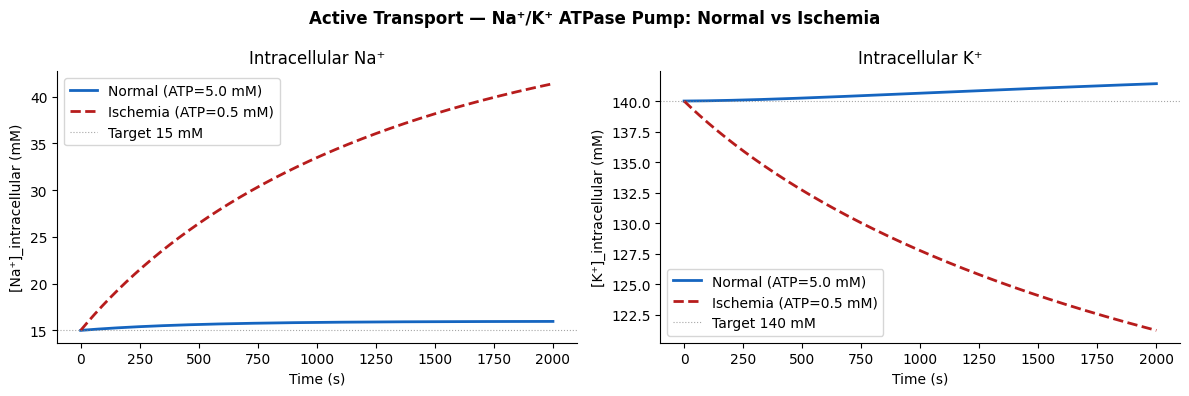

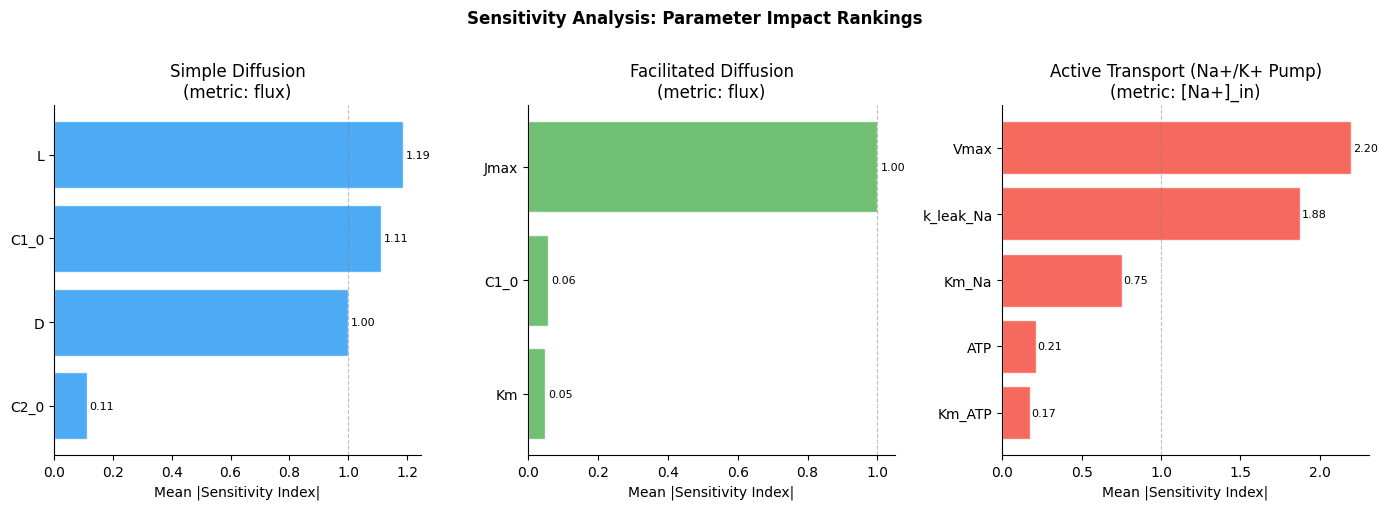

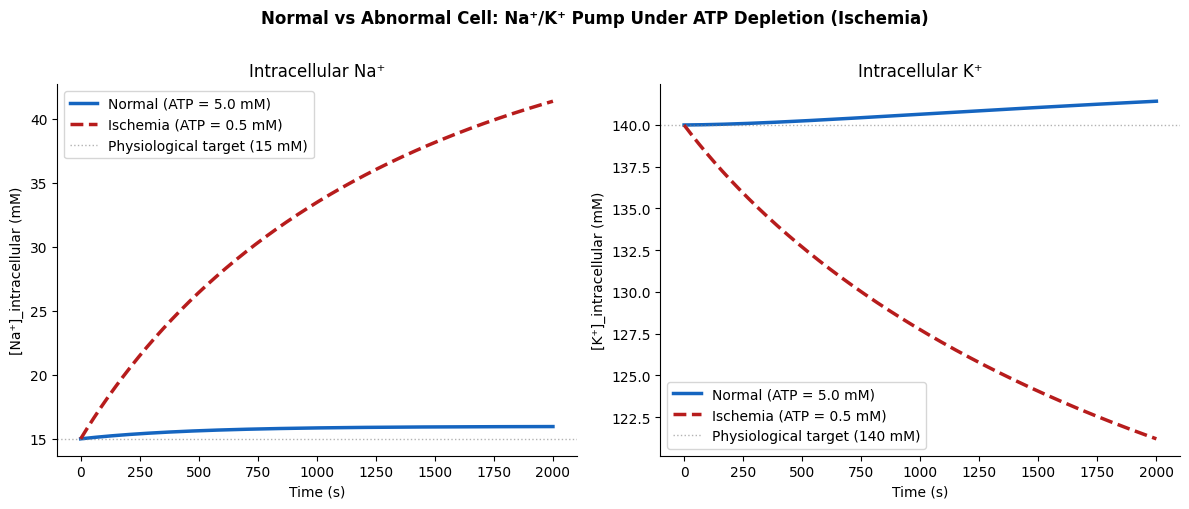

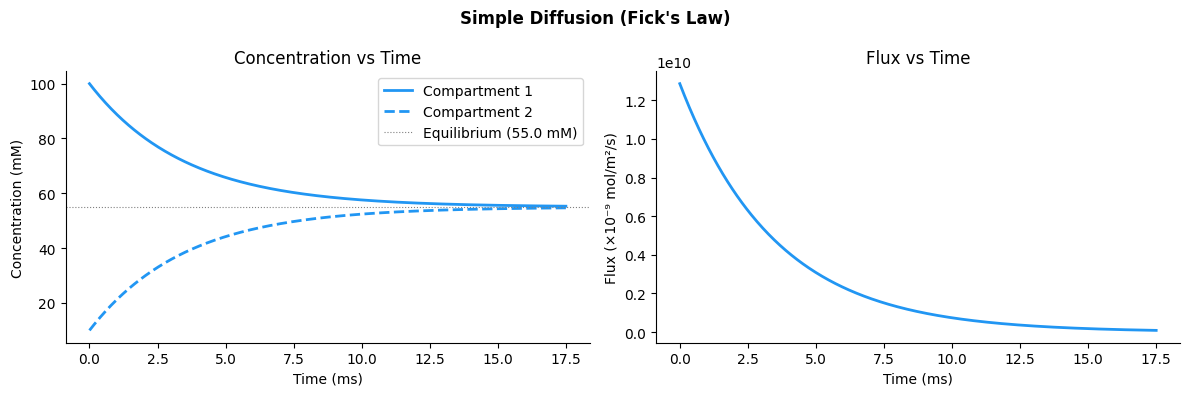

In [10]:
from simple_diffusion import simulate as sd_simulate

# Parameters from dataset
D    = p('D')
L    = p('L')
C1_0 = p('C1_0')
C2_0 = p('C2_0')
V    = 1e-15   # compartment volume [m³] — not in dataset, standard value
A    = 1e-12   # membrane area [m²] — not in dataset, standard value

t_sd, J_sd, C1_sd, C2_sd = sd_simulate(D=D, L=L, C1_0=C1_0, C2_0=C2_0, V=V, A=A)

tau = t_sd[-1] / 5.0
J0  = D * (C1_0 - C2_0) * 1000.0 / L
C_eq = (C1_sd[-1] + C2_sd[-1]) / 2

print('Simple Diffusion Results')
print(f'  D (diffusion coefficient) : {D:.2e} m²/s')
print(f'  L (membrane thickness)    : {L*1e9:.1f} nm')
print(f'  C1 initial                : {C1_0*1000:.1f} mM')
print(f'  C2 initial                : {C2_0*1000:.1f} mM')
print(f'  Time constant τ           : {tau*1000:.4f} ms')
print(f'  Initial flux J₀           : {J0:.4e} mol/m²/s')
print(f'  Final flux                : {J_sd[-1]:.4e} mol/m²/s')
print(f'  Equilibrium concentration : {C_eq*1000:.2f} mM')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Simple Diffusion (Fick\'s Law)', fontweight='bold')

t_ms = t_sd * 1000
ax = axes[0]
ax.plot(t_ms, C1_sd * 1000, color='#2196F3', lw=2, label='Compartment 1')
ax.plot(t_ms, C2_sd * 1000, color='#2196F3', lw=2, ls='--', label='Compartment 2')
ax.axhline(C_eq * 1000, color='gray', lw=0.8, ls=':', label=f'Equilibrium ({C_eq*1000:.1f} mM)')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Concentration (mM)')
ax.set_title('Concentration vs Time')
ax.legend()
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.plot(t_ms, J_sd * 1e9, color='#2196F3', lw=2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Flux (×10⁻⁹ mol/m²/s)')
ax.set_title('Flux vs Time')
ax.spines[['top','right']].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'plot_simple_diffusion.png'), bbox_inches='tight', dpi=120)
plt.show()

## 2. Facilitated Diffusion

**Facilitated diffusion** moves molecules down their concentration gradient using membrane transport proteins (channels or carriers). Unlike simple diffusion, the transport rate **saturates** at high concentrations because binding sites on the transporter become fully occupied — analogous to enzyme kinetics.

Transport flux follows **Michaelis-Menten kinetics**:

$$J = J_{max} \cdot \frac{C}{K_m + C}$$

where $J_{max}$ is the maximum flux (all transporters occupied) and $K_m$ is the half-saturation concentration (affinity constant). Examples include GLUT glucose transporters and aquaporin water channels.

Facilitated Diffusion Results
  Jmax                      : 1.00e-05 mol/m²/s
  Km                        : 5.0 mM
  C1 initial                : 100.0 mM
  C2 initial                : 10.0 mM
  Initial flux J₀           : 2.8571e-06 mol/m²/s
  Final flux                : 3.6477e-09 mol/m²/s
  Equilibrium concentration : 55.00 mM
  Saturation at t=0         : 28.6% of Jmax


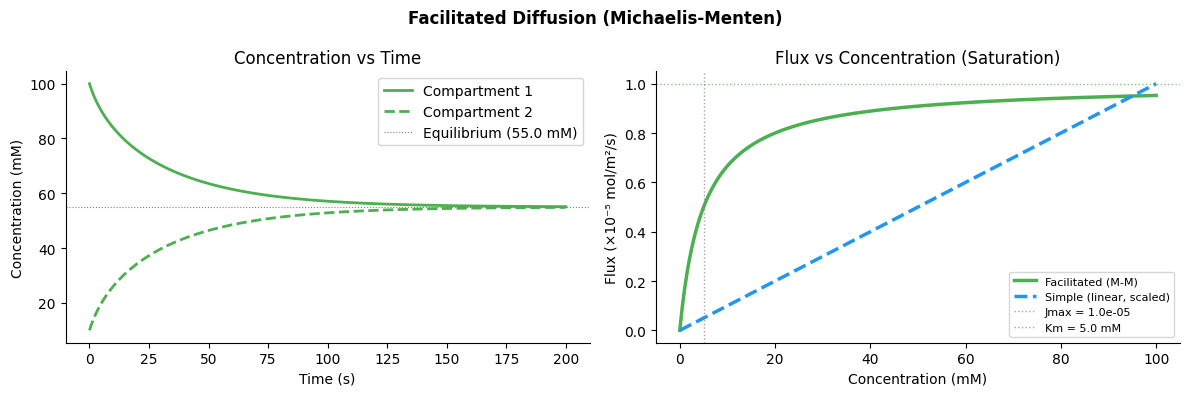

In [11]:
from facilitated_diffusion import simulate as fd_simulate, flux_vs_concentration

# Parameters from dataset
Jmax    = p('Jmax')
Km      = p('Km')
FD_C1_0 = p('C1_0')   # reuse same initial concentrations
FD_C2_0 = p('C2_0')

t_fd, J_fd, C1_fd, C2_fd = fd_simulate(Jmax=Jmax, Km=Km, C1_0=FD_C1_0, C2_0=FD_C2_0)
C_fd_eq = (C1_fd[-1] + C2_fd[-1]) / 2

print('Facilitated Diffusion Results')
print(f'  Jmax                      : {Jmax:.2e} mol/m²/s')
print(f'  Km                        : {Km*1000:.1f} mM')
print(f'  C1 initial                : {FD_C1_0*1000:.1f} mM')
print(f'  C2 initial                : {FD_C2_0*1000:.1f} mM')
print(f'  Initial flux J₀           : {J_fd[0]:.4e} mol/m²/s')
print(f'  Final flux                : {J_fd[-1]:.4e} mol/m²/s')
print(f'  Equilibrium concentration : {C_fd_eq*1000:.2f} mM')
print(f'  Saturation at t=0         : {J_fd[0]/Jmax*100:.1f}% of Jmax')

# Saturation curve
C_range, J_sat = flux_vs_concentration(Jmax=Jmax, Km=Km)
J_simple_lin = D * C_range * 1000 / L
scale = Jmax / J_simple_lin.max() if J_simple_lin.max() > 0 else 1.0

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Facilitated Diffusion (Michaelis-Menten)', fontweight='bold')

ax = axes[0]
ax.plot(t_fd, C1_fd * 1000, color='#4CAF50', lw=2, label='Compartment 1')
ax.plot(t_fd, C2_fd * 1000, color='#4CAF50', lw=2, ls='--', label='Compartment 2')
ax.axhline(C_fd_eq * 1000, color='gray', lw=0.8, ls=':', label=f'Equilibrium ({C_fd_eq*1000:.1f} mM)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Concentration (mM)')
ax.set_title('Concentration vs Time')
ax.legend()
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.plot(C_range * 1000, J_sat * 1e5, color='#4CAF50', lw=2.5, label='Facilitated (M-M)')
ax.plot(C_range * 1000, J_simple_lin * scale * 1e5, color='#2196F3', lw=2.5, ls='--', label='Simple (linear, scaled)')
ax.axhline(Jmax * 1e5, color='#4CAF50', lw=1, ls=':', alpha=0.7, label=f'Jmax = {Jmax:.1e}')
ax.axvline(Km * 1000, color='gray', lw=1, ls=':', alpha=0.7, label=f'Km = {Km*1000:.1f} mM')
ax.set_xlabel('Concentration (mM)')
ax.set_ylabel('Flux (×10⁻⁵ mol/m²/s)')
ax.set_title('Flux vs Concentration (Saturation)')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'plot_facilitated_diffusion.png'), bbox_inches='tight', dpi=120)
plt.show()

## 3. Active Transport (Na⁺/K⁺ Pump)

**Active transport** moves ions **against** their electrochemical gradients using ATP hydrolysis. The **Na⁺/K⁺-ATPase pump** (discovered by Jens Skou, Nobel Prize 1997) transports **3 Na⁺ out** and **2 K⁺ in** per ATP hydrolyzed.

This creates and maintains the resting membrane potential critical for nerve impulse transmission and muscle contraction. The pump kinetics follow a cooperative Michaelis-Menten model:

$$J_{pump} = V_{max} \cdot \frac{[Na^+]_{in}}{K_{m,Na} + [Na^+]_{in}} \cdot \frac{[K^+]_{out}}{K_{m,K} + [K^+]_{out}} \cdot \frac{[ATP]}{K_{m,ATP} + [ATP]}$$

During **ischemia** (reduced blood flow), ATP falls from ~5 mM to ~0.5 mM, impairing the pump and causing dangerous ion imbalance.

Active Transport — Na⁺/K⁺ ATPase Pump
  Vmax   : 5.00e-05 mol/L/s
  Km_Na  : 10.0 mM
  Km_K   : 1.5 mM
  Km_ATP : 0.5 mM

  NORMAL (ATP = 5.0 mM)
    Na⁺_in : 15.0 → 16.0 mM  (target: ~15 mM)
    K⁺_in  : 140.0 → 141.4 mM  (target: ~140 mM)
    Pump rate at SS: 21.4961 µmol/L/s

  ISCHEMIA (ATP = 0.5 mM)
    Na⁺_in : 15.0 → 41.4 mM  (↑ indicates pump failure)
    K⁺_in  : 140.0 → 121.2 mM  (↓ indicates pump failure)
    Pump rate at SS: 15.4885 µmol/L/s
    Pump impairment: 27.9%


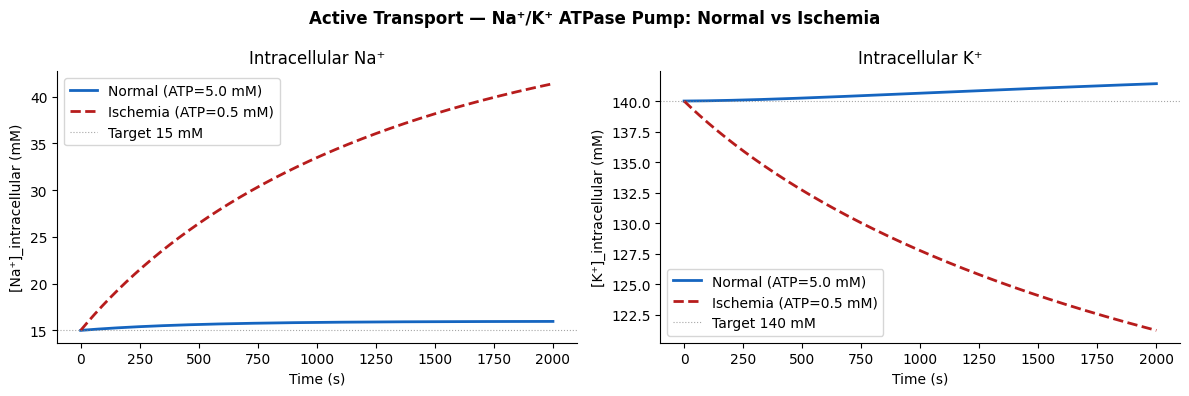

In [12]:
from active_transport import simulate as at_simulate

# Parameters from dataset
Na_in_0     = p('Na_in')
Na_out      = p('Na_out')
K_in_0      = p('K_in')
K_out       = p('K_out')
ATP_normal  = p('ATP_normal')
ATP_ischemia= p('ATP_ischemia')
Vmax        = p('Vmax')
Km_Na       = p('Km_Na')
Km_K        = p('Km_K')
Km_ATP      = p('Km_ATP')

# Run both scenarios
t_n,  Jp_n,  Na_n,  K_n  = at_simulate(
    Na_in_0=Na_in_0, Na_out=Na_out, K_in_0=K_in_0, K_out=K_out,
    ATP=ATP_normal,  Vmax=Vmax, Km_Na=Km_Na, Km_K=Km_K, Km_ATP=Km_ATP)

t_a,  Jp_a,  Na_a,  K_a  = at_simulate(
    Na_in_0=Na_in_0, Na_out=Na_out, K_in_0=K_in_0, K_out=K_out,
    ATP=ATP_ischemia, Vmax=Vmax, Km_Na=Km_Na, Km_K=Km_K, Km_ATP=Km_ATP)

print('Active Transport — Na⁺/K⁺ ATPase Pump')
print(f'  Vmax   : {Vmax:.2e} mol/L/s')
print(f'  Km_Na  : {Km_Na*1000:.1f} mM')
print(f'  Km_K   : {Km_K*1000:.1f} mM')
print(f'  Km_ATP : {Km_ATP*1000:.1f} mM')
print()
print(f'  NORMAL (ATP = {ATP_normal*1000:.1f} mM)')
print(f'    Na⁺_in : {Na_in_0*1000:.1f} → {Na_n[-1]*1000:.1f} mM  (target: ~15 mM)')
print(f'    K⁺_in  : {K_in_0*1000:.1f} → {K_n[-1]*1000:.1f} mM  (target: ~140 mM)')
print(f'    Pump rate at SS: {Jp_n[-1]*1e6:.4f} µmol/L/s')
print()
print(f'  ISCHEMIA (ATP = {ATP_ischemia*1000:.1f} mM)')
print(f'    Na⁺_in : {Na_in_0*1000:.1f} → {Na_a[-1]*1000:.1f} mM  (↑ indicates pump failure)')
print(f'    K⁺_in  : {K_in_0*1000:.1f} → {K_a[-1]*1000:.1f} mM  (↓ indicates pump failure)')
print(f'    Pump rate at SS: {Jp_a[-1]*1e6:.4f} µmol/L/s')
print(f'    Pump impairment: {(1 - Jp_a[-1]/Jp_n[-1])*100:.1f}%')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Active Transport — Na⁺/K⁺ ATPase Pump: Normal vs Ischemia', fontweight='bold')

ax = axes[0]
ax.plot(t_n, Na_n * 1000, color='#1565C0', lw=2, label=f'Normal (ATP={ATP_normal*1000:.1f} mM)')
ax.plot(t_a, Na_a * 1000, color='#B71C1C', lw=2, ls='--', label=f'Ischemia (ATP={ATP_ischemia*1000:.1f} mM)')
ax.axhline(15, color='gray', lw=0.8, ls=':', alpha=0.7, label='Target 15 mM')
ax.set_xlabel('Time (s)')
ax.set_ylabel('[Na⁺]_intracellular (mM)')
ax.set_title('Intracellular Na⁺')
ax.legend()
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.plot(t_n, K_n * 1000, color='#1565C0', lw=2, label=f'Normal (ATP={ATP_normal*1000:.1f} mM)')
ax.plot(t_a, K_a * 1000, color='#B71C1C', lw=2, ls='--', label=f'Ischemia (ATP={ATP_ischemia*1000:.1f} mM)')
ax.axhline(140, color='gray', lw=0.8, ls=':', alpha=0.7, label='Target 140 mM')
ax.set_xlabel('Time (s)')
ax.set_ylabel('[K⁺]_intracellular (mM)')
ax.set_title('Intracellular K⁺')
ax.legend()
ax.spines[['top','right']].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'plot_active_transport.png'), bbox_inches='tight', dpi=120)
plt.show()

## 4. Sensitivity Analysis

**Sensitivity analysis** quantifies how much each parameter influences the model output. We use the **elasticity coefficient** (normalized local sensitivity index):

$$S = \frac{\Delta Output / Output_{base}}{\Delta Param / Param_{base}}$$

A value of $|S| = 1$ means a 1% change in the parameter causes a 1% change in the output. Parameters with higher $|S|$ are more critical to the system's behavior and would be the most important targets for experimental measurement or therapeutic intervention.

Each parameter is perturbed by −50%, −20%, +20%, and +50% from baseline.


  Simple Diffusion
  Parameter         Mean |Sensitivity|  Rank
  ---------------------------------------------
  L                             1.1875  #1
  C1_0                          1.1111  #2
  D                             1.0000  #3
  C2_0                          0.1111  #4

  Facilitated Diffusion
  Parameter         Mean |Sensitivity|  Rank
  ---------------------------------------------
  Jmax                          1.0000  #1
  C1_0                          0.0555  #2
  Km                            0.0476  #3

  Active Transport (Na+/K+ Pump)
  Parameter         Mean |Sensitivity|  Rank
  ---------------------------------------------
  Vmax                          2.1994  #1
  k_leak_Na                     1.8752  #2
  Km_Na                         0.7514  #3
  ATP                           0.2113  #4
  Km_ATP                        0.1750  #5


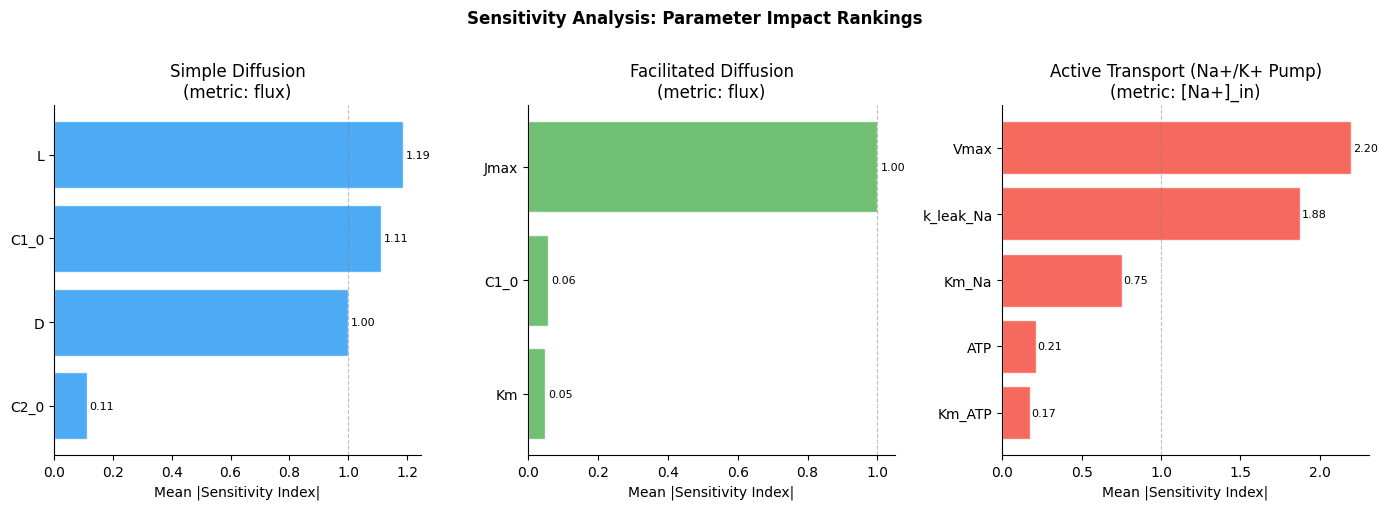

In [13]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'membrane_transport'))
from sensitivity_analysis import (
    analyze_simple_diffusion, analyze_facilitated_diffusion,
    analyze_active_transport, print_summary, PERTURBATIONS
)

# Build param dicts from dataset
sd_params = {'D': p('D'), 'L': p('L'), 'C1_0': p('C1_0'), 'C2_0': p('C2_0')}
fd_params = {'Jmax': p('Jmax'), 'Km': p('Km'), 'C1_0': p('C1_0')}
at_params = {
    'Vmax': p('Vmax'), 'Km_Na': p('Km_Na'), 'Km_ATP': p('Km_ATP'),
    'k_leak_Na': 5e-4,   # leak constant — not in dataset, standard value
    'ATP': p('ATP_normal'),
}

sd_res = analyze_simple_diffusion(sd_params)
fd_res = analyze_facilitated_diffusion(fd_params)
at_res = analyze_active_transport(at_params)

for res in [sd_res, fd_res, at_res]:
    print_summary(res)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Sensitivity Analysis: Parameter Impact Rankings', fontweight='bold', y=1.01)

colors = ['#2196F3', '#4CAF50', '#F44336']
for ax, res, color in zip(axes, [sd_res, fd_res, at_res], colors):
    params = res['rankings']
    means  = [np.mean([abs(s) for _, s in res[p_]]) for p_ in params]
    bars = ax.barh(params[::-1], means[::-1], color=color, alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, means[::-1]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)
    metric = 'flux' if 'Active' not in res['model'] else '[Na+]_in'
    ax.set_xlabel('Mean |Sensitivity Index|')
    ax.set_title(f"{res['model']}\n(metric: {metric})")
    ax.axvline(1.0, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.spines[['top','right']].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'plot_sensitivity_analysis.png'), bbox_inches='tight', dpi=120)
plt.show()

## 5. Normal vs Abnormal (Ischemia)

**Ischemia** (insufficient blood supply, e.g., during a heart attack or stroke) depletes cellular ATP. With less ATP available, the Na⁺/K⁺ pump slows dramatically — it cannot maintain the ion gradients that are essential for membrane potential and cell survival.

The consequences:
- **Na⁺ accumulates intracellularly** → osmotic swelling → cell lysis
- **K⁺ leaks out** → depolarization → uncontrolled action potentials
- **Ca²⁺ influx** (via reversed Na⁺/Ca²⁺ exchanger) → apoptosis

This simulation compares the steady-state ion profiles under normal (ATP = 5 mM) vs ischemic (ATP = 0.5 mM) conditions, illustrating the physiological consequence of pump failure.

Normal vs Ischemia Comparison
                                     Normal     Ischemia
--------------------------------------------------------
ATP concentration (mM)                  5.0          0.5
Final [Na+]_in (mM)                    16.0         41.4
Final [K+]_in (mM)                    141.4        121.2
Pump rate at SS (µmol/L/s)          21.4961      15.4885
Pump impairment (%)                       —        27.9%


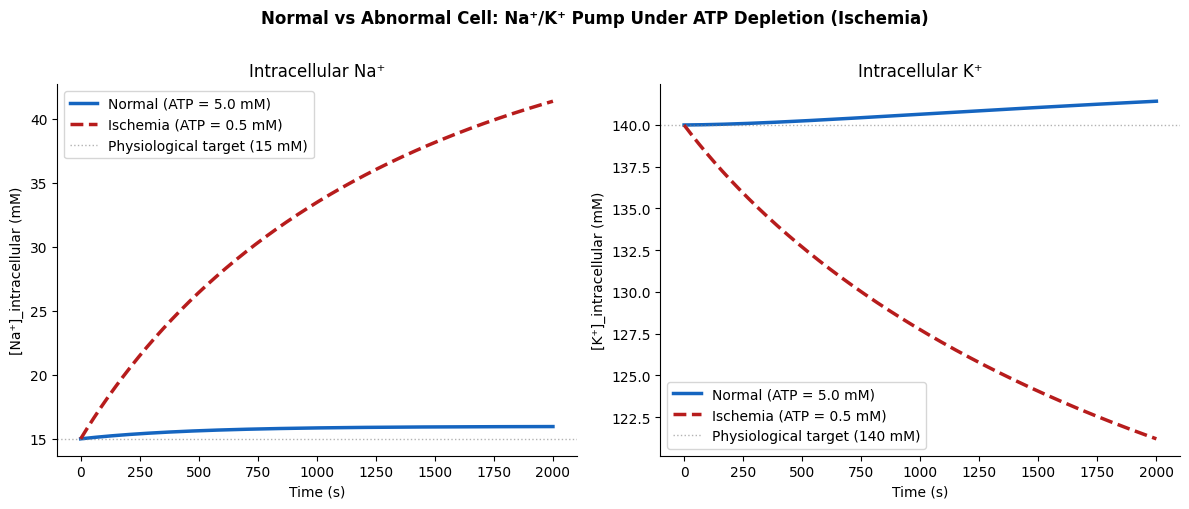

In [14]:
# Data already computed in Cell 8 (t_n, Na_n, K_n, t_a, Na_a, K_a)
# Re-run simulation in case cells are executed out of order
from active_transport import simulate as at_simulate

Na_in_0      = p('Na_in')
Na_out       = p('Na_out')
K_in_0       = p('K_in')
K_out        = p('K_out')
ATP_normal   = p('ATP_normal')
ATP_ischemia = p('ATP_ischemia')
Vmax         = p('Vmax')
Km_Na        = p('Km_Na')
Km_K         = p('Km_K')
Km_ATP       = p('Km_ATP')

t_n, Jp_n, Na_n, K_n = at_simulate(
    Na_in_0=Na_in_0, Na_out=Na_out, K_in_0=K_in_0, K_out=K_out,
    ATP=ATP_normal, Vmax=Vmax, Km_Na=Km_Na, Km_K=Km_K, Km_ATP=Km_ATP)

t_a, Jp_a, Na_a, K_a = at_simulate(
    Na_in_0=Na_in_0, Na_out=Na_out, K_in_0=K_in_0, K_out=K_out,
    ATP=ATP_ischemia, Vmax=Vmax, Km_Na=Km_Na, Km_K=Km_K, Km_ATP=Km_ATP)

# Comparison table
print('Normal vs Ischemia Comparison')
print(f"{'':30} {'Normal':>12} {'Ischemia':>12}")
print('-' * 56)
print(f"{'ATP concentration (mM)':<30} {ATP_normal*1000:>12.1f} {ATP_ischemia*1000:>12.1f}")
print(f"{'Final [Na+]_in (mM)':<30} {Na_n[-1]*1000:>12.1f} {Na_a[-1]*1000:>12.1f}")
print(f"{'Final [K+]_in (mM)':<30} {K_n[-1]*1000:>12.1f} {K_a[-1]*1000:>12.1f}")
print(f"{'Pump rate at SS (µmol/L/s)':<30} {Jp_n[-1]*1e6:>12.4f} {Jp_a[-1]*1e6:>12.4f}")
print(f"{'Pump impairment (%)':<30} {'—':>12} {(1-Jp_a[-1]/Jp_n[-1])*100:>11.1f}%")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Normal vs Abnormal Cell: Na⁺/K⁺ Pump Under ATP Depletion (Ischemia)',
             fontweight='bold', y=1.01)

ax = axes[0]
ax.plot(t_n, Na_n * 1000, color='#1565C0', lw=2.5, label=f'Normal (ATP = {ATP_normal*1000:.1f} mM)')
ax.plot(t_a, Na_a * 1000, color='#B71C1C', lw=2.5, ls='--', label=f'Ischemia (ATP = {ATP_ischemia*1000:.1f} mM)')
ax.axhline(15, color='gray', lw=1, ls=':', alpha=0.6, label='Physiological target (15 mM)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('[Na⁺]_intracellular (mM)')
ax.set_title('Intracellular Na⁺')
ax.legend()
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.plot(t_n, K_n * 1000, color='#1565C0', lw=2.5, label=f'Normal (ATP = {ATP_normal*1000:.1f} mM)')
ax.plot(t_a, K_a * 1000, color='#B71C1C', lw=2.5, ls='--', label=f'Ischemia (ATP = {ATP_ischemia*1000:.1f} mM)')
ax.axhline(140, color='gray', lw=1, ls=':', alpha=0.6, label='Physiological target (140 mM)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('[K⁺]_intracellular (mM)')
ax.set_title('Intracellular K⁺')
ax.legend()
ax.spines[['top','right']].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'plot_normal_vs_ischemia.png'), bbox_inches='tight', dpi=120)
plt.show()